# Q2 风险分位数：费用最优性与稳定性图册

基于上传的 `p2.py` 与两份原始 CSV 重算。**只使用 2025-05-01 至 2025-08-31 开发期选择分位数**，候选为 5%～95%，间隔 5%。85% 是候选网格上的开发期经验最优，不表示连续区间或其他月份必然最优，也不是预测准确率。

**直接运行全部单元格即可出图**：默认使用内置的真实逐日扫描结果，无需 `q2_final.py` 或 Excel 模板。需要 numpy、pandas、matplotlib；重算另需 scipy、scikit-learn。Windows 通常自动使用微软雅黑。

全部图为中文，导出 300 dpi PNG 和矢量 PDF，不添加图片底部说明。输出目录：`q2_risk_figures`。

如需重算：将两份原始 CSV 放在 notebook 同目录或 `input` 子目录，将下方 `RECOMPUTE` 改为 `True`。计算核心取自上传的 p2.py，保留预测、场景、调度和费用定义，不强制最优值等于 85%。

In [2]:
from pathlib import Path
import io, json, base64, zlib, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from matplotlib.ticker import PercentFormatter
from IPython.display import display
ROOT = Path.cwd()
OUT = ROOT / 'q2_risk_figures'
OUT.mkdir(exist_ok=True)
RECOMPUTE = False
FONT_PATH = None  # 如需指定字体，填写 .ttf/.otf 文件路径
if FONT_PATH:
    fm.fontManager.addfont(str(FONT_PATH))
    chosen = fm.FontProperties(fname=str(FONT_PATH)).get_name()
else:
    installed = {f.name for f in fm.fontManager.ttflist}
    chosen = next((s for s in ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'PingFang SC', 'WenQuanYi Micro Hei', 'Droid Sans Fallback'] if s in installed), None)
    fallback = Path('/usr/share/ghostscript/10.02.1/Resource/CIDFSubst/DroidSansFallback.ttf')
    if chosen is None and fallback.exists():
        fm.fontManager.addfont(str(fallback))
        chosen = fm.FontProperties(fname=str(fallback)).get_name()
if chosen is None:
    raise RuntimeError('未找到中文字体。请在 FONT_PATH 填写本机中文字体文件路径后重跑。')
plt.rcParams.update({'font.family':chosen, 'axes.unicode_minus':False,
    'font.size':11, 'axes.titlesize':14, 'axes.labelsize':12,
    'axes.spines.top':False, 'axes.spines.right':False,
    'axes.grid':True, 'grid.alpha':0.18, 'grid.color':'#8b96a5',
    'figure.dpi':110, 'savefig.dpi':300, 'pdf.fonttype':42})
BLUE, ORANGE, GREEN, GRAY = '#2878A5', '#E38A38', '#3B927B', '#9AA7B1'
def finish(fig, name):
    fig.savefig(OUT / (name+'.png'), bbox_inches='tight', facecolor='white')
    fig.savefig(OUT / (name+'.pdf'), bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)


In [3]:
SOURCE_SHA256 = {'p2.py': '16e936a9f1e37e2761f49d0bc07ffdffe1fb24bb6967e07bf61c8a6333308f90', 'q2_actual_load_pv.csv': 'a5194bfbfef875d15d382b2fba5d88bcbb330460cbc4ebf38df79168189c9dbf', 'q2_fixed_prices.csv': '9b11897f3585248cbd934c6988331fa8156611db87c9d9db7ad51adae43d76a7'}
# 19 个分位数 × 123 天；压缩的是实际重算数据，不是拟合或示意数据。
CACHED_DAILY_B64 = '...'
daily = pd.read_csv(io.BytesIO(zlib.decompress(base64.b64decode(CACHED_DAILY_B64))))


In [4]:
# 内置原脚本计算核心，仅在 RECOMPUTE=True 时载入及执行。
CORE_SOURCE = 'from __future__ import annotations\n\nfrom pathlib import Path\nfrom copy import copy\nimport argparse\nimport json\nimport time\n\nimport numpy as np\nimport pandas as pd\nfrom scipy.optimize import linprog, Bounds, LinearConstraint, milp\nfrom scipy.sparse import coo_matrix, csr_matrix, hstack\nfrom sklearn.linear_model import Ridge\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.pipeline import make_pipeline\n\nSCRIPT_DIR = Path(__file__).resolve().parent\n\n# ============================================================\n# Q2 FINAL FROZEN CONFIGURATION\n# ============================================================\nFORECAST = {\n    "window_days": 60,          # maximum rolling window; warm-up uses all available history\n    "k_load": 3,\n    "k_pv": 2,\n    "alpha_load": 0.3,\n    "alpha_pv": 10.0,\n    "scenario_days": 28,        # maximum paired residual scenario window\n}\nQ_GRID = np.round(np.arange(0.05, 0.951, 0.05), 2)\nEXPECTED_Q_STAR = 0.85\n\nDEV_START, DEV_END = "2025-05-01", "2025-08-31"\nRUN_START, RUN_END = "2025-02-01", "2025-12-31"\n\nCFG = {\n    "eta_c": 0.9,\n    "eta_d": 0.9,\n    "storage_min_kwh": 1200.0,\n    "storage_max_kwh": 10800.0,\n    "initial_storage_kwh": 6000.0,\n    "terminal_storage_kwh": 6000.0,\n    "max_charge_kw": 5000.0,\n    "max_discharge_kw": 5000.0,\n    "emergency_multiplier": 5.0,\n    "interval_hours": 1.0 / 6.0,\n}\n\ndef require(cond, msg):\n    if not cond:\n        raise AssertionError(msg)\n\ndef resolve_existing(candidates):\n    for p in candidates:\n        p = Path(p)\n        if p.exists():\n            return p\n    return Path(candidates[0])\n\ndef default_paths():\n    actual = resolve_existing([\n        SCRIPT_DIR / "input" / "q2_actual_load_pv.csv",\n        SCRIPT_DIR / "q2_actual_load_pv.csv",\n        SCRIPT_DIR.parent / "q2" / "input" / "q2_actual_load_pv.csv",\n    ])\n    price = resolve_existing([\n        SCRIPT_DIR / "input" / "q2_fixed_prices.csv",\n        SCRIPT_DIR / "q2_fixed_prices.csv",\n        SCRIPT_DIR.parent / "q2" / "input" / "q2_fixed_prices.csv",\n    ])\n    template = resolve_existing([\n        SCRIPT_DIR / "input" / "result2_template.xlsx",\n        SCRIPT_DIR / "result2_template.xlsx",\n        SCRIPT_DIR.parent / "Data_preprocessed" / "raw" / "附件5" / "result2.xlsx",\n    ])\n    return actual, price, template\n\ndef load_inputs(actual_path, price_path):\n    x = pd.read_csv(actual_path, encoding="utf-8-sig")\n    x["date"] = pd.to_datetime(x["date"])\n    x = x.sort_values(["date", "slot"]).reset_index(drop=True)\n\n    require(len(x) == 365 * 144, "q2_actual_load_pv.csv 必须是 365×144=52560 行")\n    require(x[["load_kw", "pv_kw"]].notna().all().all(), "Load/PV 存在缺失值")\n    require((x[["load_kw", "pv_kw"]] >= 0).all().all(), "Load/PV 存在负值")\n    require(x[["date", "slot"]].duplicated().sum() == 0, "存在重复 date-slot")\n    counts = x.groupby("date")["slot"].nunique()\n    require((counts == 144).all(), "存在某日不是 144 个时段")\n\n    dates = pd.DatetimeIndex(x["date"].drop_duplicates())\n    load = x["load_kw"].to_numpy(float).reshape(-1, 144)\n    pv = x["pv_kw"].to_numpy(float).reshape(-1, 144)\n\n    p = pd.read_csv(price_path, encoding="utf-8-sig").sort_values("slot")\n    require(len(p) == 144, "q2_fixed_prices.csv 必须为 144 行")\n    prices = p["price_yuan_per_kwh"].to_numpy(float)\n    require(np.isfinite(prices).all() and (prices > 0).all(), "电价数据非法")\n    return dates, load, pv, prices\n\ndef pca_basis(curves, k):\n    mu = curves.mean(axis=0)\n    _, _, vt = np.linalg.svd(curves - mu, full_matrices=False)\n    return mu, vt[:k]\n\ndef weekday7(date):\n    x = np.zeros(7)\n    x[date.weekday()] = 1.0\n    return x\n\ndef annual1(date):\n    a = 2.0 * np.pi * date.dayofyear / 365.25\n    return np.array([np.sin(a), np.cos(a)])\n\ndef forecast_scenarios(dates, load, pv):\n    """\n    Causal rolling forecast.\n\n    Important:\n    - W=60 is the maximum history length, not available on Feb-01.\n    - During warm-up, all available completed history is used.\n    - Residual scenario bank uses at most the latest 28 completed days.\n    - Today\'s actual Load/PV is appended to the residual bank only AFTER today\'s\n      scenario is constructed, so there is no same-day look-ahead leakage.\n    """\n    W = FORECAST["window_days"]\n    KL = FORECAST["k_load"]\n    KP = FORECAST["k_pv"]\n    AL = FORECAST["alpha_load"]\n    AP = FORECAST["alpha_pv"]\n    S = FORECAST["scenario_days"]\n\n    pred_l = np.full_like(load, np.nan)\n    pred_p = np.full_like(pv, np.nan)\n    scenarios = {}\n    residuals = []\n\n    # Need at least 7 lag days + a small training set.\n    for d in range(14, len(dates)):\n        h0 = max(0, d - W)\n\n        mu_l, phi_l = pca_basis(load[h0:d], KL)\n        mu_p, phi_p = pca_basis(pv[h0:d], KP)\n\n        sl = (load[h0:d] - mu_l) @ phi_l.T\n        sp = (pv[h0:d] - mu_p) @ phi_p.T\n\n        train_days = np.arange(max(h0 + 7, 7), d)\n\n        def f_load(j):\n            jj = j - h0\n            return np.r_[weekday7(dates[j]), sl[jj - 1]]\n\n        def f_pv(j):\n            jj = j - h0\n            return np.r_[\n                annual1(dates[j]),\n                sp[jj - 1],\n                sp[jj - 7],\n                sp[jj - 7:jj].mean(axis=0),\n            ]\n\n        XL = np.vstack([f_load(j) for j in train_days])\n        XP = np.vstack([f_pv(j) for j in train_days])\n        yL = np.vstack([sl[j - h0] for j in train_days])\n        yP = np.vstack([sp[j - h0] for j in train_days])\n\n        model_l = make_pipeline(StandardScaler(), Ridge(alpha=AL))\n        model_p = make_pipeline(StandardScaler(), Ridge(alpha=AP))\n        model_l.fit(XL, yL)\n        model_p.fit(XP, yP)\n\n        sh_l = np.atleast_1d(model_l.predict(f_load(d)[None, :])[0])\n        sh_p = np.atleast_1d(model_p.predict(f_pv(d)[None, :])[0])\n\n        pred_l[d] = np.maximum(mu_l + sh_l @ phi_l, 0)\n        pred_p[d] = np.maximum(mu_p + sh_p @ phi_p, 0)\n\n        if residuals:\n            recent = residuals[-S:]\n            eL = np.array([r[1] for r in recent])\n            eP = np.array([r[2] for r in recent])\n            # Keep same-day Load/PV residual pairing; clip physical Load/PV to nonnegative.\n            scenarios[d] = (\n                np.maximum(pred_l[d][None, :] + eL, 0)\n                - np.maximum(pred_p[d][None, :] + eP, 0)\n            )\n\n        residuals.append((d, load[d] - pred_l[d], pv[d] - pred_p[d]))\n\n    return pred_l, pred_p, scenarios\n\ndef solve_dispatch(net_kwh, prices):\n    """Daily storage dispatch LP; if simultaneous c/d appears, switch to MILP."""\n    net = np.asarray(net_kwh, float)\n    n = len(net)\n    require(n == 144, "每日必须 144 个时段")\n\n    eta_c, eta_d = CFG["eta_c"], CFG["eta_d"]\n    cmax = CFG["max_charge_kw"] * CFG["interval_hours"]\n    dmax = CFG["max_discharge_kw"] * CFG["interval_hours"]\n    emin, emax = CFG["storage_min_kwh"], CFG["storage_max_kwh"]\n\n    # x = [grid, charge, discharge, unused, E_0...E_144]\n    count = 5 * n + 1\n    obj = np.zeros(count)\n    obj[:n] = prices\n\n    rows, cols, data = [], [], []\n    rhs = np.zeros(2 * n)\n    t = np.arange(n)\n\n    # planned energy balance: g + d - c - u = net\n    for rr, cc, dd in [\n        (t, t, np.ones(n)),\n        (t, 2*n+t, np.ones(n)),\n        (t, n+t, -np.ones(n)),\n        (t, 3*n+t, -np.ones(n)),\n    ]:\n        rows.extend(rr); cols.extend(cc); data.extend(dd)\n    rhs[:n] = net\n\n    # storage recursion\n    r = n + t\n    for rr, cc, dd in [\n        (r, 4*n+t+1, np.ones(n)),\n        (r, 4*n+t, -np.ones(n)),\n        (r, n+t, -eta_c*np.ones(n)),\n        (r, 2*n+t, np.ones(n)/eta_d),\n    ]:\n        rows.extend(rr); cols.extend(cc); data.extend(dd)\n\n    Aeq = coo_matrix((data, (rows, cols)), shape=(2*n, count)).tocsr()\n\n    lower = np.zeros(count)\n    upper = np.full(count, np.inf)\n    upper[n:2*n] = cmax\n    upper[2*n:3*n] = dmax\n    lower[4*n:] = emin\n    upper[4*n:] = emax\n    lower[4*n] = upper[4*n] = CFG["initial_storage_kwh"]\n    lower[5*n] = upper[5*n] = CFG["terminal_storage_kwh"]\n\n    res = linprog(\n        obj,\n        A_eq=Aeq,\n        b_eq=rhs,\n        bounds=np.column_stack([lower, upper]),\n        method="highs",\n    )\n    require(res.success, "LP 求解失败: " + res.message)\n    x = res.x\n    solver = "LP"\n\n    overlap = (x[n:2*n] > 1e-7) & (x[2*n:3*n] > 1e-7)\n    if overlap.any():\n        # binary z_t: c_t <= cmax*z_t, d_t <= dmax*(1-z_t)\n        m = count + n\n        mode_rows = np.r_[t, t, n+t, n+t]\n        mode_cols = np.r_[n+t, count+t, 2*n+t, count+t]\n        mode_data = np.r_[\n            np.ones(n), -cmax*np.ones(n),\n            np.ones(n), dmax*np.ones(n),\n        ]\n        mode = coo_matrix((mode_data, (mode_rows, mode_cols)), shape=(2*n, m)).tocsr()\n\n        res2 = milp(\n            np.r_[obj, np.zeros(n)],\n            integrality=np.r_[np.zeros(count), np.ones(n)],\n            bounds=Bounds(\n                np.r_[lower, np.zeros(n)],\n                np.r_[upper, np.ones(n)],\n            ),\n            constraints=[\n                LinearConstraint(\n                    hstack([Aeq, csr_matrix((2*n, n))]),\n                    rhs, rhs,\n                ),\n                LinearConstraint(\n                    mode,\n                    -np.inf,\n                    np.r_[np.zeros(n), dmax*np.ones(n)],\n                ),\n            ],\n            options={"mip_rel_gap": 1e-8},\n        )\n        require(res2.success, "MILP 求解失败: " + res2.message)\n        x = res2.x[:count]\n        solver = "MILP"\n\n    return {\n        "grid": np.maximum(x[:n], 0),\n        "charge": np.maximum(x[n:2*n], 0),\n        "discharge": np.maximum(x[2*n:3*n], 0),\n        "unused_plan": np.maximum(x[3*n:4*n], 0),\n        "storage": x[4*n:],\n        "solver": solver,\n        "max_plan_balance_residual": float(np.max(np.abs(Aeq @ x - rhs))),\n    }\n\ndef execute_fixed_plan(plan, actual_net_kwh):\n    supply = plan["grid"] + plan["discharge"] - plan["charge"]\n    emergency = np.maximum(actual_net_kwh - supply, 0)\n    unused = np.maximum(supply - actual_net_kwh, 0)\n    balance = (\n        plan["grid"] + plan["discharge"] + emergency\n        - actual_net_kwh - plan["charge"] - unused\n    )\n    require(np.max(np.abs(balance)) < 1e-6, "实际执行能量平衡失败")\n    return emergency, unused\n\ndef run_q(dates, load, pv, prices, scenarios, day_idx, q, keep_slots=False):\n    daily, slots = [], []\n\n    for d in day_idx:\n        qnet_kw = np.quantile(scenarios[d], q, axis=0)\n        plan = solve_dispatch(qnet_kw * CFG["interval_hours"], prices)\n\n        actual_net_kwh = (load[d] - pv[d]) * CFG["interval_hours"]\n        emergency, unused = execute_fixed_plan(plan, actual_net_kwh)\n\n        planned_cost = float(prices @ plan["grid"])\n        emergency_cost = float(\n            CFG["emergency_multiplier"] * prices @ emergency\n        )\n\n        daily.append({\n            "q": float(q),\n            "date": str(dates[d].date()),\n            "planned_grid_kwh": float(plan["grid"].sum()),\n            "planned_charge_kwh": float(plan["charge"].sum()),\n            "planned_discharge_kwh": float(plan["discharge"].sum()),\n            "emergency_kwh": float(emergency.sum()),\n            "unused_kwh": float(unused.sum()),\n            "planned_cost_yuan": planned_cost,\n            "emergency_cost_yuan": emergency_cost,\n            "total_cost_yuan": planned_cost + emergency_cost,\n            "emergency_slots": int((emergency > 1e-7).sum()),\n            "solver": plan["solver"],\n            "max_balance_residual": plan["max_plan_balance_residual"],\n            "min_storage_kwh": float(plan["storage"].min()),\n            "max_storage_kwh": float(plan["storage"].max()),\n        })\n\n        if keep_slots:\n            for t in range(144):\n                slots.append({\n                    "date": str(dates[d].date()),\n                    "slot": t + 1,\n                    "forecast_net_q85_kw": float(qnet_kw[t]),\n                    "actual_load_kw": float(load[d, t]),\n                    "actual_pv_kw": float(pv[d, t]),\n                    "actual_net_kwh": float(actual_net_kwh[t]),\n                    "price_yuan_per_kwh": float(prices[t]),\n                    "planned_grid_kwh": float(plan["grid"][t]),\n                    "planned_charge_kwh": float(plan["charge"][t]),\n                    "planned_discharge_kwh": float(plan["discharge"][t]),\n                    "planned_storage_start_kwh": float(plan["storage"][t]),\n                    "planned_storage_end_kwh": float(plan["storage"][t+1]),\n                    "emergency_kwh": float(emergency[t]),\n                    "unused_kwh": float(unused[t]),\n                })\n\n    return pd.DataFrame(daily), pd.DataFrame(slots)\n\n'
if RECOMPUTE:
    ns = {'__file__':str(ROOT/'p2.py'), '__name__':'q2_embedded_core'}
    exec(compile(CORE_SOURCE, 'p2_embedded_core', 'exec'), ns)
    def locate(name):
        for p in [ROOT/'input'/name, ROOT/name, ROOT/'q2'/'input'/name]:
            if p.exists(): return p
        raise FileNotFoundError(f'请将 {name} 放在当前目录或 input 子目录：{ROOT}')
    actual, price = locate('q2_actual_load_pv.csv'), locate('q2_fixed_prices.csv')
    dates, load, pv, prices = ns['load_inputs'](actual, price)
    _, _, scenarios = ns['forecast_scenarios'](dates, load, pv)
    ix = np.where((dates >= pd.Timestamp('2025-05-01')) & (dates <= pd.Timestamp('2025-08-31')))[0]
    rows = []
    for q in ns['Q_GRID']:
        result, _ = ns['run_q'](dates, load, pv, prices, scenarios, ix, float(q))
        rows.append(result)
        print(f'q={q:.0%}，总费用={result.total_cost_yuan.sum():,.2f} 元', flush=True)
    daily = pd.concat(rows, ignore_index=True)
    SOURCE_SHA256 = {p.name:hashlib.sha256(p.read_bytes()).hexdigest() for p in [actual, price]}
    SOURCE_SHA256['embedded_core'] = hashlib.sha256(CORE_SOURCE.encode()).hexdigest()


## 1. 结果核验与自动选择
按总费用最小选取候选分位数。所有月度图都属于开发期内部诊断，不能当作独立测试集验证。

In [5]:
daily['date'] = pd.to_datetime(daily['date'])
expected_dates = pd.date_range('2025-05-01', '2025-08-31')
assert not daily.duplicated(['q','date']).any(), '存在重复的分位数-日期'
assert np.allclose(sorted(daily.q.unique()), np.arange(.05,.951,.05))
for q, g in daily.groupby('q'):
    assert pd.DatetimeIndex(g.date.sort_values()).equals(expected_dates), f'{q} 日期不完整'
cols = ['planned_cost_yuan','emergency_cost_yuan','total_cost_yuan','emergency_kwh']
assert np.isfinite(daily[cols].to_numpy()).all()
assert np.allclose(daily.total_cost_yuan, daily.planned_cost_yuan+daily.emergency_cost_yuan)
scan = daily.groupby('q', as_index=False)[cols].sum().sort_values('q')
best = scan.loc[scan.total_cost_yuan.idxmin()]
q_star, best_cost = float(best.q), float(best.total_cost_yuan)
scan['extra_cost_yuan'] = scan.total_cost_yuan-best_cost
scan['extra_cost_pct'] = scan.extra_cost_yuan/best_cost*100
print(f'开发期网格最优 q*={q_star:.0%}；总费用={best_cost:,.2f} 元')
print('85% 是否为当前数据的网格最优：', bool(np.isclose(q_star,.85)))
display(scan.rename(columns={'q':'风险分位数','planned_cost_yuan':'计划购电费（元）','emergency_cost_yuan':'紧急购电费（元）','total_cost_yuan':'总费用（元）','emergency_kwh':'紧急购电量（kWh）','extra_cost_yuan':'比最优多花（元）','extra_cost_pct':'比最优多花（%）'}).round(4))
daily.to_csv(OUT/'development_daily_scan.csv',index=False,encoding='utf-8-sig')
scan.to_csv(OUT/'development_scan_summary.csv',index=False,encoding='utf-8-sig')
(OUT/'provenance.json').write_text(json.dumps({'period':['2025-05-01','2025-08-31'],'q_star':q_star,'source_sha256':SOURCE_SHA256,'mode':'recomputed' if RECOMPUTE else 'embedded_verified_results'},ensure_ascii=False,indent=2),encoding='utf-8')


开发期网格最优 q*=85%；总费用=5,425,712.46 元
85% 是否为当前数据的网格最优： True


,风险分位数,计划购电费（元）,紧急购电费（元）,总费用（元）,紧急购电量（kWh）,比最优多花（元）,比最优多花（%）
0,0.05,3.817155e+06,4.918071e+06,8.735226e+06,1.262387e+06,3.309514e+06,60.9968
1,0.10,3.930494e+06,4.204492e+06,8.134986e+06,1.075756e+06,2.709274e+06,49.9340
2,0.15,4.015760e+06,3.697511e+06,7.713271e+06,9.415336e+05,2.287558e+06,42.1614
3,0.20,4.090931e+06,3.273267e+06,7.364197e+06,8.318582e+05,1.938485e+06,35.7277
4,0.25,4.161540e+06,2.896575e+06,7.058115e+06,7.348281e+05,1.632403e+06,30.0864
5,0.30,4.227216e+06,2.572832e+06,6.800048e+06,6.520443e+05,1.374335e+06,25.3300
6,0.35,4.290622e+06,2.275963e+06,6.566586e+06,5.766386e+05,1.140873e+06,21.0272
7,0.40,4.351057e+06,2.011451e+06,6.362508e+06,5.094753e+05,9.367959e+05,17.2659
8,0.45,4.409927e+06,1.776644e+06,6.186570e+06,4.503228e+05,7.608578e+05,14.0232
9,0.50,4.470771e+06,1.556576e+06,6.027347e+06,3.941439e+05,6.016349e+05,11.0886


411

## 2. 总费用与最优点（论文主图）
左图展示完整扫描，右图放大高分位区间。标记由数据自动决定，不将 85% 写死为最优。

MERG NOT subset; don't know how to subset; dropped


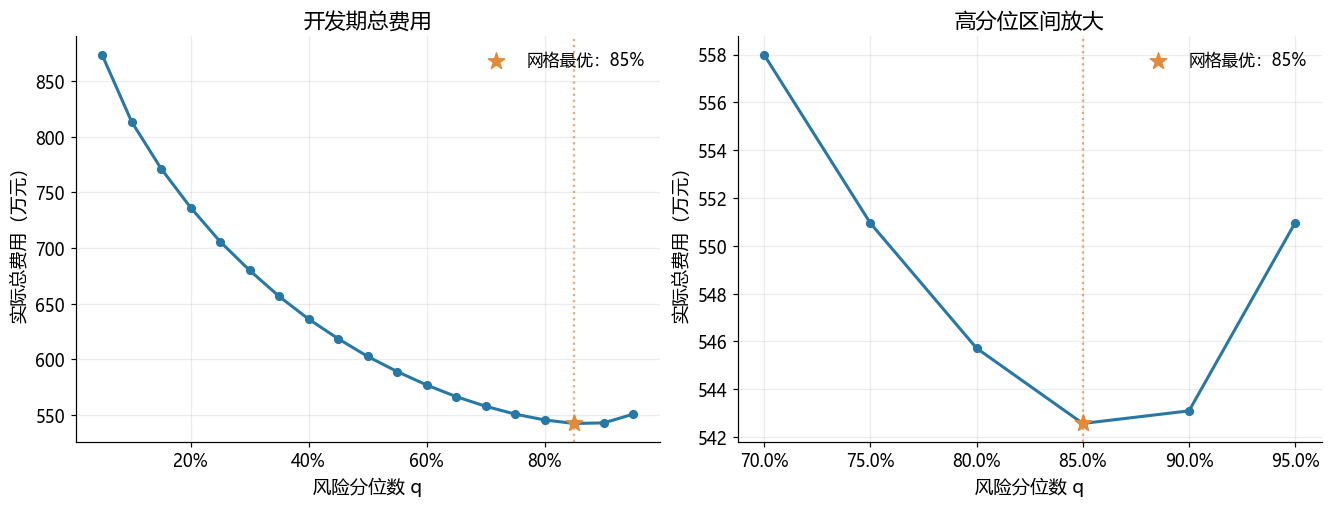

In [6]:
fig, axes = plt.subplots(1,2,figsize=(12,4.5),layout='constrained')
for ax, part, title in [(axes[0],scan,'开发期总费用'),(axes[1],scan[scan.q>=.70],'高分位区间放大')]:
    ax.plot(part.q,part.total_cost_yuan/1e4,'o-',color=BLUE,lw=2,ms=5)
    ax.scatter([q_star],[best_cost/1e4],s=125,color=ORANGE,marker='*',zorder=4,label=f'网格最优：{q_star:.0%}')
    ax.axvline(q_star,color=ORANGE,ls=':',alpha=.7)
    ax.set(title=title,xlabel='风险分位数 q',ylabel='实际总费用（万元）')
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.legend(frameon=False,loc='upper right')
    ax.ticklabel_format(axis='y',style='plain',useOffset=False)
axes[1].set_xticks(scan.loc[scan.q>=.70,'q'])
finish(fig,'01_分位数总费用与最优点')


## 3. 费用分解
同时展示计划购电费、紧急购电费和总费用，解释增加计划采购与减少紧急补购之间的权衡。

MERG NOT subset; don't know how to subset; dropped


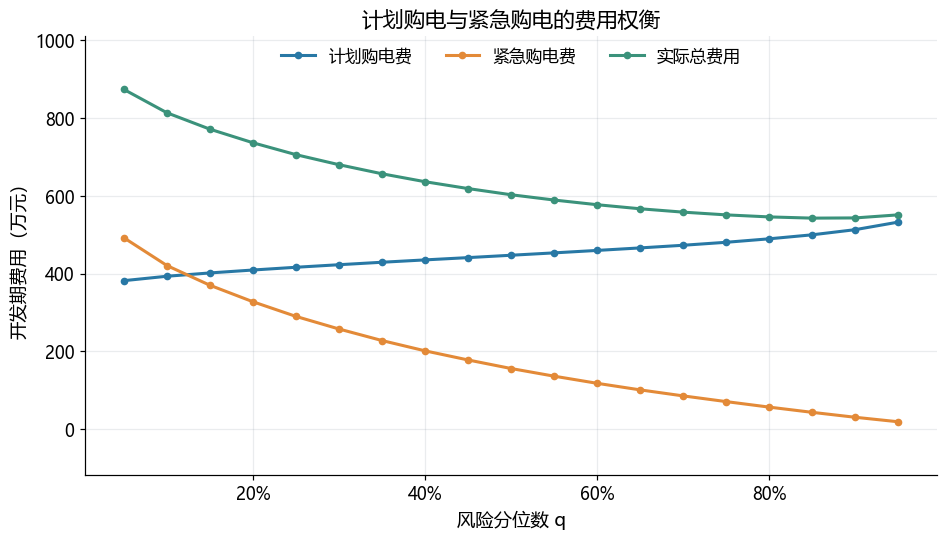

In [7]:
fig,ax=plt.subplots(figsize=(8.5,4.8),layout='constrained')
for col,label,color in [('planned_cost_yuan','计划购电费',BLUE),('emergency_cost_yuan','紧急购电费',ORANGE),('total_cost_yuan','实际总费用',GREEN)]:
    ax.plot(scan.q,scan[col]/1e4,'o-',label=label,color=color,lw=2,ms=4)
ax.set(xlabel='风险分位数 q',ylabel='开发期费用（万元）',title='计划购电与紧急购电的费用权衡')
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.legend(loc='upper center',bbox_to_anchor=(.5,1.01),ncol=3,frameon=False)
ax.margins(y=.16)
finish(fig,'02_计划与紧急购电费用分解')


## 4. 最优附近到底差多少
以开发期最优总费用为基准，展示邻近候选的额外费用比例；接近零不代表统计上显著不同。

MERG NOT subset; don't know how to subset; dropped


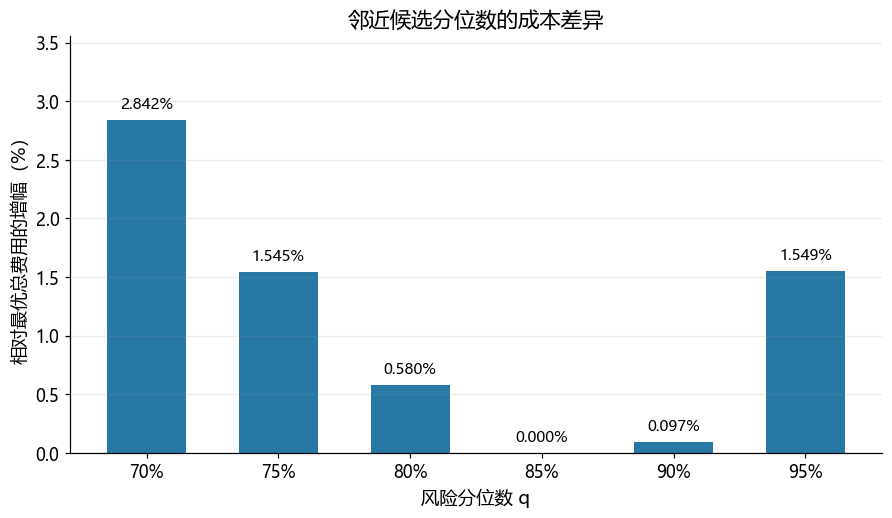

In [8]:
near=scan[scan.q>=.70]
fig,ax=plt.subplots(figsize=(8,4.6),layout='constrained')
colors=[ORANGE if np.isclose(q,q_star) else BLUE for q in near.q]
bars=ax.bar(np.arange(len(near)),near.extra_cost_pct,color=colors,width=.6)
ax.bar_label(bars,labels=[f'{v:.3f}%' for v in near.extra_cost_pct],padding=5,fontsize=10)
ax.set_xticks(np.arange(len(near)),[f'{q:.0%}' for q in near.q])
ax.set(xlabel='风险分位数 q',ylabel='相对最优总费用的增幅（%）',title='邻近候选分位数的成本差异')
ax.set_ylim(0,max(near.extra_cost_pct.max()*1.25,.1))
ax.grid(axis='x',visible=False)
finish(fig,'03_邻近分位数额外费用')


## 5. 开发期月度稳定性
每条线以该月自身的最优费用为基准。星号标记每月最优点，虚线标记整个开发期最优点；月度最优无需全部相同。

MERG NOT subset; don't know how to subset; dropped


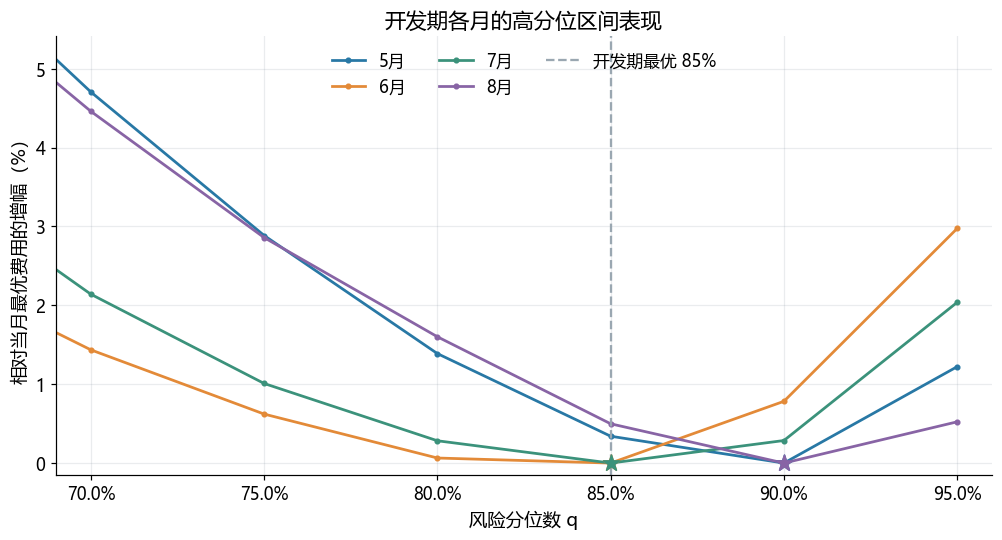

In [9]:
monthly=daily.assign(month=daily.date.dt.month).groupby(['month','q'],as_index=False).total_cost_yuan.sum()
fig,ax=plt.subplots(figsize=(9,4.8),layout='constrained')
for (month,g),color in zip(monthly.groupby('month'),[BLUE,ORANGE,GREEN,'#8864A5']):
    g=g.sort_values('q'); m=g.total_cost_yuan.min(); y=(g.total_cost_yuan/m-1)*100
    ax.plot(g.q,y,'o-',color=color,label=f'{month}月',ms=3,lw=1.8)
    b=g.loc[g.total_cost_yuan.idxmin()]
    ax.scatter([b.q],[0],marker='*',s=120,color=color,zorder=4)
ax.axvline(q_star,color=GRAY,ls='--',label=f'开发期最优 {q_star:.0%}')
ax.set(xlim=(.69,.96),xlabel='风险分位数 q',ylabel='相对当月最优费用的增幅（%）',title='开发期各月的高分位区间表现')
visible=monthly[monthly.q>=.70].copy()
visible['relative']=visible.groupby('month').total_cost_yuan.transform(lambda x:(x/x.min()-1)*100)
ax.set_ylim(-.15,max(visible.relative.max()*1.15,.5))
ax.set_xticks(np.arange(.70,.951,.05));ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.legend(frameon=False,ncol=3,loc='upper center')
finish(fig,'04_开发期月度稳定性')
monthly.to_csv(OUT/'monthly_scan.csv',index=False,encoding='utf-8-sig')


## 6. 紧急购电量随分位数变化
分位数不是实际保供率。该图展示在固定计划执行机制下，提高分位数对开发期紧急购电量的影响。

MERG NOT subset; don't know how to subset; dropped


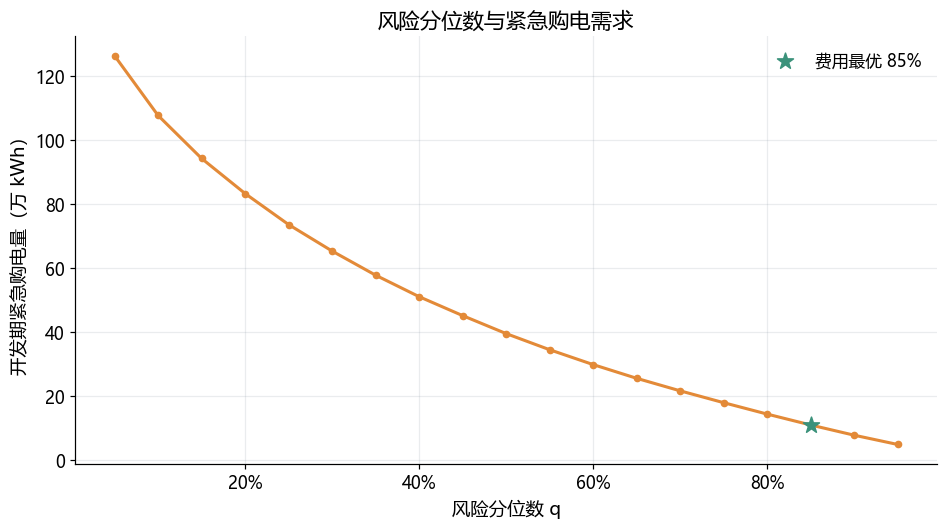

已导出 5 组 PNG/PDF 和配套 CSV： E:\桌面\CUMCM_2026\q2\q2_risk_figures


In [10]:
fig,ax=plt.subplots(figsize=(8.5,4.7),layout='constrained')
ax.plot(scan.q,scan.emergency_kwh/1e4,'o-',color=ORANGE,lw=2,ms=4)
ax.scatter([q_star],[best.emergency_kwh/1e4],color=GREEN,s=120,marker='*',label=f'费用最优 {q_star:.0%}',zorder=4)
ax.set(xlabel='风险分位数 q',ylabel='开发期紧急购电量（万 kWh）',title='风险分位数与紧急购电需求')
ax.xaxis.set_major_formatter(PercentFormatter(1));ax.legend(frameon=False)
finish(fig,'05_紧急购电量变化')
print('已导出 5 组 PNG/PDF 和配套 CSV：',OUT.resolve())
